## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

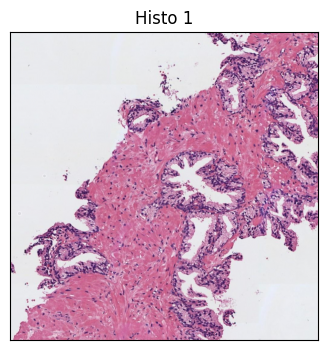

In [1]:
import math

from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from skimage import io
import numpy as np
import cv2

def get_imagen_original_normalizada(ruta_imagen):
    # Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
    img = io.imread(ruta_imagen)
    
    # Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
    rgb = img.copy()
    rgb_normalizada = rgb.astype('uint8')/255

    return rgb, rgb_normalizada

def visualizar_imagen(imagen, titulo):
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    axes.imshow(imagen, cmap='gray');   
    axes.set_title(titulo);        
    axes.set_xticks([]); 
    axes.set_yticks([])
    axes.set_visible(True)
    plt.show()

histo_1, histo_1_normalizada = get_imagen_original_normalizada('./histo_1.jpg')
visualizar_imagen(histo_1_normalizada, "Histo 1")

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

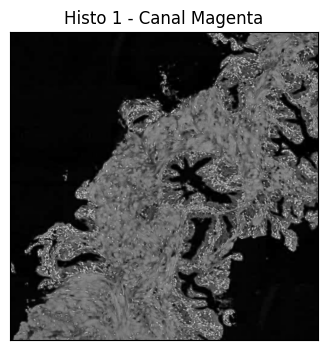

In [2]:
def obtener_CMYK(imagen_normalizada):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(imagen_normalizada, axis=2)
        C = (1-imagen_normalizada[:,:,0]-K)/(1-K)
        M = (1-imagen_normalizada[:,:,1]-K)/(1-K)
        Y = (1-imagen_normalizada[:,:,2]-K)/(1-K)
    
    CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
    C,M,Y,K = cv2.split(CMYK)
    return C,M,Y,K
    
    
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
histo_1_C, histo_1_M, histo_1_Y, histo_1_K = obtener_CMYK(histo_1_normalizada)

visualizar_imagen(histo_1_M.astype('uint8'), 'Histo 1 - Canal Magenta')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

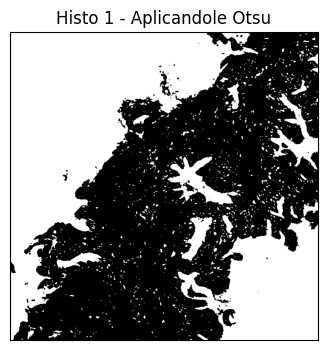

In [3]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

def transformar_imagen_a_float32(imagen):
  imagen_float_32 = imagen.astype(np.float32)
  return imagen_float_32


def aplicar_filtro_gauss_outsu_y_visualizar(imagen):
    imagen_32 = transformar_imagen_a_float32(imagen) # Se transforma a 32 float para poder escalar a grices con cv2.cvtColor
    imagen_32_gray = cv2.cvtColor(imagen_32, cv2.COLOR_BGR2GRAY)
    imagen_gray_u8 = (imagen_32_gray.astype(np.float32) * 255).clip(0, 255).astype(np.uint8) # Se pasa a u8 la escala de grises para poder graficar

    gaussian_blur = cv2.GaussianBlur(imagen_gray_u8, (5, 5), 0)
    _, gaussian_blur_mask = cv2.threshold(gaussian_blur, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_mask = cv2.threshold(gaussian_blur_mask, 0, 1, cv2.THRESH_OTSU)

    visualizar_imagen(otsu_mask, "Histo 1 - Aplicandole Otsu")

    return otsu_mask

histo_1_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_1_normalizada)

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

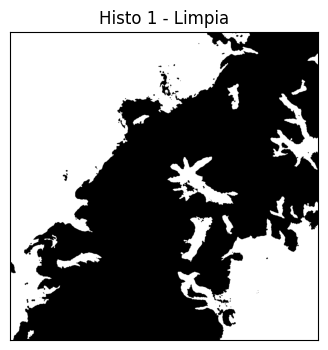

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante
from skimage.morphology import remove_small_objects

histo_1_bool = histo_1_otsu_mask.astype(bool)
histo_1_limpia = remove_small_objects(histo_1_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_1_limpia, "Histo 1 - Limpia")

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

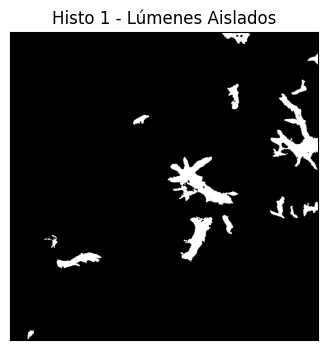

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

def rellenar_fondo(imagen):
    # Crear una copia de la imagen
    imagen_copia = imagen.copy()
    
    # Definir una imagen negra de referencia
    h, w = imagen.shape
    ref = np.zeros((h+2, w+2), np.uint8)
    
    # Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (0, 0), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    # Fijar la semilla. En este caso en la esquina inferior derecha (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (h - 1, w - 1), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    return imagen_copia

histo_1_lumenes = rellenar_fondo(histo_1_limpia)
visualizar_imagen(histo_1_lumenes, "Histo 1 - Lúmenes Aislados")

#### 5) Rellenar los objetos de los lúmenes

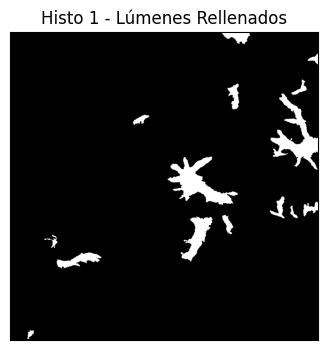

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante
from  scipy.ndimage import binary_fill_holes

histo_1_lumenes_fill = binary_fill_holes(histo_1_lumenes.copy())
visualizar_imagen(histo_1_lumenes_fill, "Histo 1 - Lúmenes Rellenados")

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

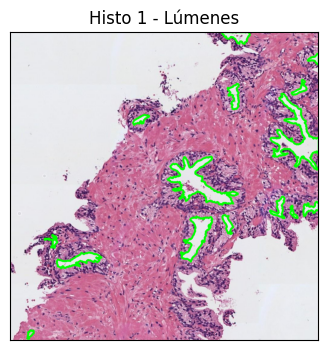

In [7]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta
from skimage.measure import regionprops
from skimage.measure import label
from skimage.morphology import convex_hull_image

def contornear_lumenes(imagen_mascara, imagen_original):
    imagen = imagen_original.copy()
    
    contours, _ = cv2.findContours(imagen_mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) # Encontramos los contornos en una máscara
    imagen = cv2.drawContours(imagen, contours, -1, (0,255,0), 5) # Dibujamos los contornos

    return imagen

histo_1_etiquetas, histo_1_num_etiquetas = label(histo_1_lumenes_fill, return_num=True)
histo_1_con_contorno = contornear_lumenes(imagen_mascara = histo_1_lumenes_fill.astype(np.uint8), imagen_original= histo_1)
visualizar_imagen(histo_1_con_contorno, "Histo 1 - Lúmenes")

#### 7) Identificar y cropear el lumen más grande

El lumen 7 tiene el mayor área: 13367.0


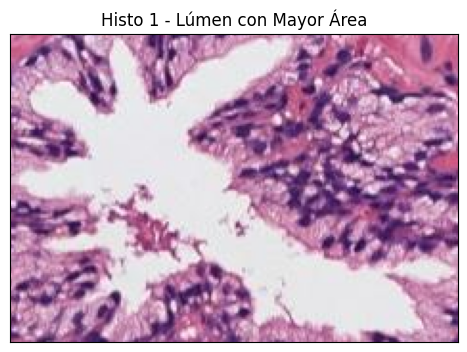

In [8]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

def obtener_propiedades_lumenes(etiquetas, num_etiquetas):
    A,BB,CA,E,ED,EX, DF, MA,MiA,OR,P,S,CO = ['Área'], ['Área de la bounding box'], ['Área convexa'],  \
    ['Exentricidad'], ['Diámetro equivalente'], ['Extensión'], ['Diámetro Feret'],  \
    ['Longitud del eje mayor'], ['Longitud del eje menor'], ['Orientación'], ['Perímetro'], \
    ['Solidez'], ['Compacidad']
    
    for i in range(1, num_etiquetas + 1):
        lumen = etiquetas == i
        lumen = lumen.astype('uint8')
    
        prop = regionprops(lumen.astype(np.uint8))

        A.append(np.round(prop[0].area, 4))
        BB.append(np.round(prop[0].bbox_area, 4))
        CA.append(np.round(prop[0].convex_area, 4))
        E.append(np.round(prop[0].eccentricity, 4))
        ED.append(np.round(prop[0].equivalent_diameter, 4))
        EX.append(np.round(prop[0].extent, 4))
        DF.append(np.round(prop[0].feret_diameter_max, 4))
        MA.append(np.round(prop[0].major_axis_length, 4))
        MiA.append(np.round(prop[0].minor_axis_length, 4))
        OR.append(np.round(prop[0].orientation, 4))
        P.append(np.round(prop[0].perimeter, 4))
        S.append(np.round(prop[0].solidity, 4))
        CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))

    propiedades = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), tuple(DF), \
          tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO)]

    return propiedades

def crop_lumen_con_mayor_area(imagen, etiquetas, propiedades):
    areas = np.array(propiedades[0][1:])
    posicion = areas.argmax() + 1
    print(f"El lumen {posicion} tiene el mayor área: {areas.max()}")

    lumen = etiquetas == posicion
    lumen = lumen.astype('uint8')
    prop = regionprops(lumen.astype(np.uint8))
    minr, minc, maxr, maxc = prop[0].bbox
    return imagen[minr:maxr, minc:maxc]
    
histo_1_propiedades = obtener_propiedades_lumenes(histo_1_etiquetas, histo_1_num_etiquetas)
histo_1_crop = crop_lumen_con_mayor_area(histo_1, histo_1_etiquetas, histo_1_propiedades)
visualizar_imagen(histo_1_crop, "Histo 1 - Lúmen con Mayor Área")

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [9]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

def tabular_informacion(propiedades):
    num = len(propiedades[0]) - 1
    headers = [f"Lumen {num}" for num in range(1, num + 1)]
    html_table = tabulate(propiedades, headers=headers, tablefmt="html")
    display(HTML(html_table))

tabular_informacion(histo_1_propiedades)

,Lumen 1,Lumen 2,Lumen 3,Lumen 4,Lumen 5,Lumen 6,Lumen 7,Lumen 8,Lumen 9,Lumen 10,Lumen 11,Lumen 12,Lumen 13,Lumen 14,Lumen 15
Área,2288,647,820,1821,12595,836,13367,1377,1249,378,1085,6327,481,3499,347
Área de la bounding box,3800,1406,2550,3230,40894,1870,37674,3577,2548,1050,2368,16006,1892,7897,660
Área convexa,2709,851,1373,2465,27955,1059,27468,2339,1892,570,1436,9540,1226,5250,435
Exentricidad,0.9207,0.6399,0.8986,0.937,0.7757,0.9331,0.8443,0.8745,0.8678,0.9518,0.9436,0.9438,0.5885,0.9784,0.8782
Diámetro equivalente,53.9738,28.7017,32.3119,48.1515,126.635,32.6256,130.458,41.8718,39.8783,21.9382,37.1681,89.754,24.7473,66.7463,21.0194
Extensión,0.6021,0.4602,0.3216,0.5638,0.308,0.4471,0.3548,0.385,0.4902,0.36,0.4582,0.3953,0.2542,0.4431,0.5258
Diámetro Feret,95.7549,42.9418,60.6053,86.6833,279.652,60.0083,243.463,73.3348,64.8151,46.5188,68.1542,167.538,45.4533,150.473,34.4093
Longitud del eje mayor,94.3932,39.2897,64.6394,92.1423,234.62,57.4903,231.451,77.891,67.2435,48.6414,69.2208,176.694,43.2667,163.08,32.0965
Longitud del eje menor,36.8439,30.194,28.3553,32.186,148.056,20.6693,124.033,37.784,33.4151,14.9169,22.9107,58.3979,34.9804,33.7241,15.3512
Orientación,1.4278,-1.5432,-0.8005,0.0808,0.3037,-1.0908,0.9965,-0.2534,-1.2487,0.441,0.3464,-0.4007,0.4207,-1.3524,-0.5882


## Se Repite el Proceso con la Segunda Imagen

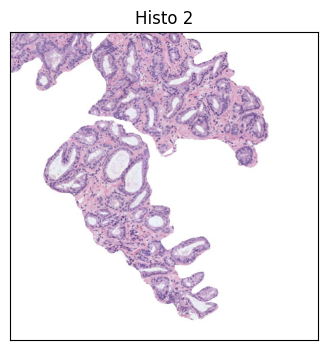

In [10]:
histo_2, histo_2_normalizada = get_imagen_original_normalizada('./histo_2.jpg')
visualizar_imagen(histo_2_normalizada, "Histo 2")

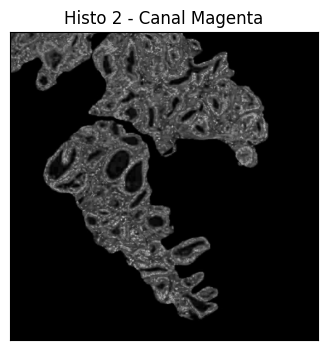

In [11]:
histo_2_C, histo_2_M, histo_2_Y, histo_2_K = obtener_CMYK(histo_2_normalizada)
visualizar_imagen(histo_2_M.astype('uint8'), 'Histo 2 - Canal Magenta')

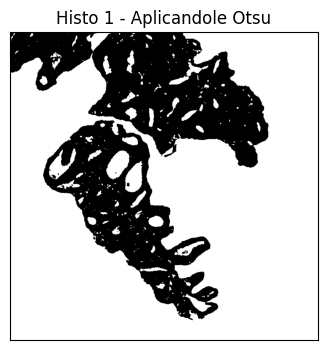

In [12]:
histo_2_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_2_normalizada)

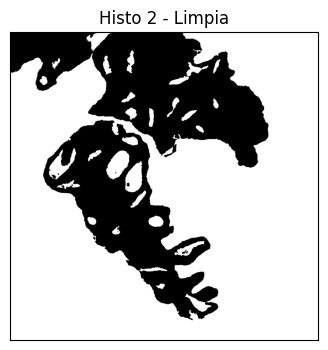

In [13]:
histo_2_bool = histo_2_otsu_mask.astype(bool)
histo_2_limpia = remove_small_objects(histo_2_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_2_limpia, "Histo 2 - Limpia")

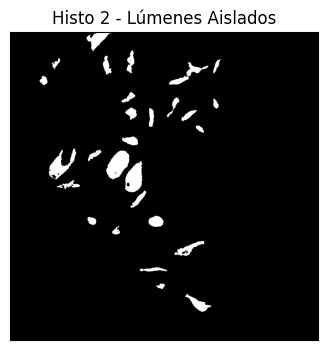

In [14]:
histo_2_lumenes = rellenar_fondo(histo_2_limpia)
visualizar_imagen(histo_2_lumenes, "Histo 2 - Lúmenes Aislados")

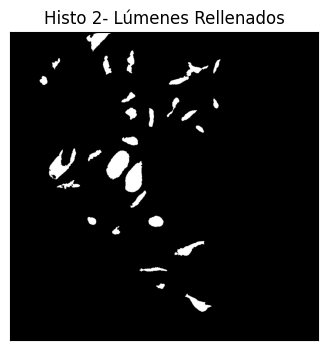

In [15]:
histo_2_lumenes_fill = binary_fill_holes(histo_2_lumenes.copy())
visualizar_imagen(histo_2_lumenes_fill, "Histo 2- Lúmenes Rellenados")

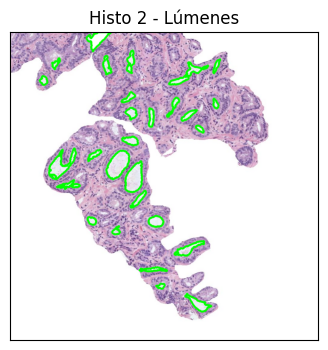

In [16]:
histo_2_etiquetas, histo_2_num_etiquetas = label(histo_2_lumenes_fill, return_num=True)
histo_2_con_contorno = contornear_lumenes(imagen_mascara = histo_2_lumenes_fill.astype(np.uint8), imagen_original= histo_2)
visualizar_imagen(histo_2_con_contorno, "Histo 2 - Lúmenes")

El lumen 18 tiene el mayor área: 4683.0


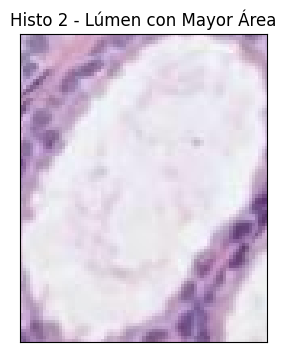

In [17]:
histo_2_propiedades = obtener_propiedades_lumenes(histo_2_etiquetas, histo_2_num_etiquetas)
histo_2_crop = crop_lumen_con_mayor_area(histo_2, histo_2_etiquetas, histo_2_propiedades)
visualizar_imagen(histo_2_crop, "Histo 2 - Lúmen con Mayor Área")

In [18]:
tabular_informacion(histo_2_propiedades)

,Lumen 1,Lumen 2,Lumen 3,Lumen 4,Lumen 5,Lumen 6,Lumen 7,Lumen 8,Lumen 9,Lumen 10,Lumen 11,Lumen 12,Lumen 13,Lumen 14,Lumen 15,Lumen 16,Lumen 17,Lumen 18,Lumen 19,Lumen 20,Lumen 21,Lumen 22,Lumen 23,Lumen 24,Lumen 25,Lumen 26,Lumen 27,Lumen 28
Área,2306,1064,958,413,444,2137,527,656,665,380,927,805,744,365,1076,3535,659,4683,4200,819,910,1405,568,413,1799,746,319,1756
Área de la bounding box,5330,1900,1827,999,1152,9825,780,1610,2665,646,1599,1071,1924,648,1590,9270,1755,7392,5824,2387,3021,1850,754,756,4851,1288,522,5280
Área convexa,2737,1419,1178,562,512,4409,565,790,1048,419,1052,913,818,389,1176,5521,787,4884,4368,1358,1040,1452,600,517,2418,1002,370,2227
Exentricidad,0.8259,0.9623,0.941,0.9044,0.9736,0.9656,0.5581,0.9359,0.9788,0.8901,0.519,0.9706,0.9609,0.8998,0.874,0.8514,0.9575,0.8377,0.8558,0.9605,0.9775,0.6882,0.7016,0.562,0.9662,0.9918,0.8022,0.9358
Diámetro equivalente,54.1857,36.8066,34.9251,22.9314,23.7764,52.1624,25.9036,28.9006,29.0982,21.9962,34.3554,32.015,30.7781,21.5577,37.0136,67.0888,28.9666,77.2177,73.1273,32.2922,34.0389,42.2954,26.8924,22.9314,47.8598,30.8194,20.1535,47.2843
Extensión,0.4326,0.56,0.5244,0.4134,0.3854,0.2175,0.6756,0.4075,0.2495,0.5882,0.5797,0.7516,0.3867,0.5633,0.6767,0.3813,0.3755,0.6335,0.7212,0.3431,0.3012,0.7595,0.7533,0.5463,0.3709,0.5792,0.6111,0.3326
Diámetro Feret,88.459,76.2365,63.0714,40.3113,52.3927,144.506,30.8058,50.5668,72.45,35.4401,41.1947,63.3877,61.8547,33.0151,55.9732,123.847,55.4437,104.317,110.309,77.2334,74.5185,50.636,33.8378,32.8024,107.935,92.0217,29.4279,94.3398
Longitud del eje mayor,79.4469,76.3856,63.8504,38.8074,50.8416,143.374,28.9081,52.8221,80.0814,33.4073,38.2212,67.9805,59.2652,32.8445,54.3716,115.754,56.1626,104.778,103.263,75.6442,75.2943,49.7797,32.0844,27.6344,103.955,92.9006,27.2124,87.084
Longitud del eje menor,44.7908,20.7685,21.6038,16.5617,11.6154,37.2745,23.9873,18.6004,16.4126,15.2283,32.6708,16.3708,16.417,14.3282,26.4218,60.7204,16.1903,57.2181,53.4132,21.0415,15.899,36.1157,22.861,22.8583,26.7996,11.8989,16.2473,30.7
Orientación,-0.9512,-0.14,0.1834,-0.6873,-0.3924,-1.0135,0.1551,-0.944,-0.4618,0.3091,0.6713,-0.0129,-0.9472,0.8859,1.3772,-0.7953,-0.9782,-0.5628,-0.2865,-1.4846,-0.7155,1.5165,0.9674,-0.7578,-1.1129,-1.5476,-1.3628,0.9987
